In [21]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("ggplot")
from scipy.integrate import solve_ivp
from matplotlib.gridspec import GridSpec
from scipy.optimize import fsolve
import warnings
warnings.filterwarnings('ignore')

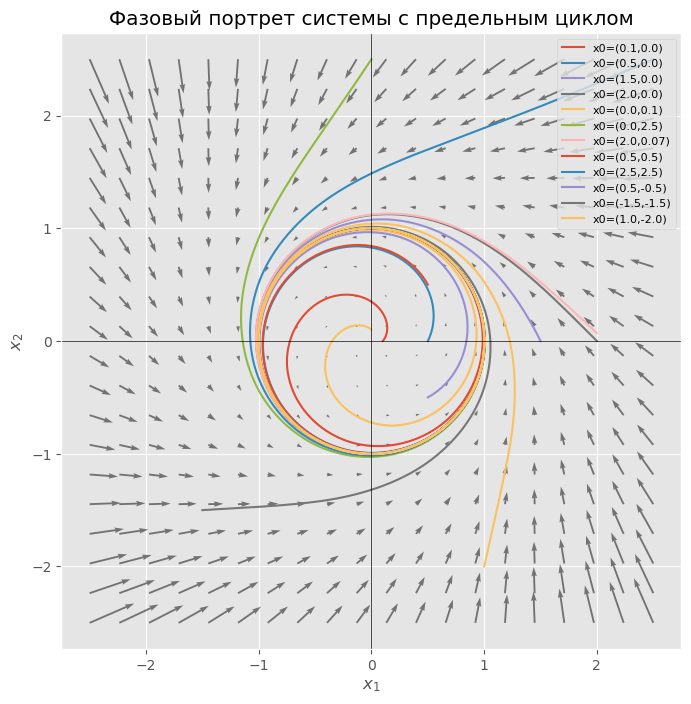

In [11]:
# Система ОДУ
def system(t, X):
    x1, x2 = X
    r = np.sqrt(x1**2 + x2**2)
    dx1 = -x2 + x1 * (1 - r)
    dx2 = x1 + x2 * (1 - r)
    return [dx1, dx2]

# Параметры интегрирования
t_span = (0, 20)
t_eval = np.linspace(0, 20, 2000)

# Начальные условия
initial_conditions = [[0.1, 0.0], [0.5, 0.0], [1.5, 0.0],
                      [2.0, 0.0], [0.0, 0.1], [0.0, 2.5],
                      [2.0, 0.07], [0.5, 0.5], [2.5, 2.5],
                      [0.5, -0.5], [-1.5, -1.5], [1.0, -2.0]]

# Построение фазового портрета
plt.figure(figsize=(8, 8))
for x0 in initial_conditions:
    sol = solve_ivp(system, t_span, x0, t_eval=t_eval, method='RK45')
    plt.plot(sol.y[0], sol.y[1], linewidth=1.5, label=f'x0=({x0[0]},{x0[1]})')

# векторное поле
Y, X = np.mgrid[-2.5:2.5:20j, -2.5:2.5:20j]
U = -Y + X * (1 - np.sqrt(X**2 + Y**2))
V = X + Y * (1 - np.sqrt(X**2 + Y**2))
plt.quiver(X, Y, U, V, alpha=0.5)

plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.title('Фазовый портрет системы с предельным циклом')
plt.legend(loc='upper right', fontsize=8)
plt.axis('equal')
plt.grid(True)
plt.show()

#### Генератор Ван дер Поля

1. КАЧЕСТВЕННЫЙ АНАЛИЗ ПО ПЕРВОМУ ПРИБЛИЖЕНИЮ
Система: dx/dt = y, dy/dt = 2μ(1-x²)y - x

Единственная точка покоя: (0, 0)

Линеаризованная система в окрестности (0,0):
J = [[0, 1], [-1, 2μ]]
Характеристическое уравнение: λ² - 2μλ + 1 = 0
Собственные значения: λ₁,₂ = μ ± √(μ² - 1)

Бифуркационные значения параметра μ:
  μ = -1: переход узел → фокус (для μ < 0)
  μ = 0:  бифуркация Андронова-Хопфа
  μ = 1:  переход фокус → узел (для μ > 0)

Режимы работы генератора:
μ < -1:  Устойчивый узел (апериодический режим)
-1 < μ < 0: Устойчивый фокус (затухающие колебания)
μ = 0:  Точка бифуркации (центр по первому приближению)
0 < μ < 1: Неустойчивый фокус + устойчивый предельный цикл (квазигармонические автоколебания)
μ > 1:  Неустойчивый узел + устойчивый предельный цикл (релаксационные автоколебания)

Параметрическая диаграмма:
 Бифуркация Андронова-Хопфа при μ = 0
 При μ < 0: устойчивое состояние равновесия, аттрактор - точка
 При μ > 0: рождается устойчивый предельный цикл, амплитуда ~ 2
2.

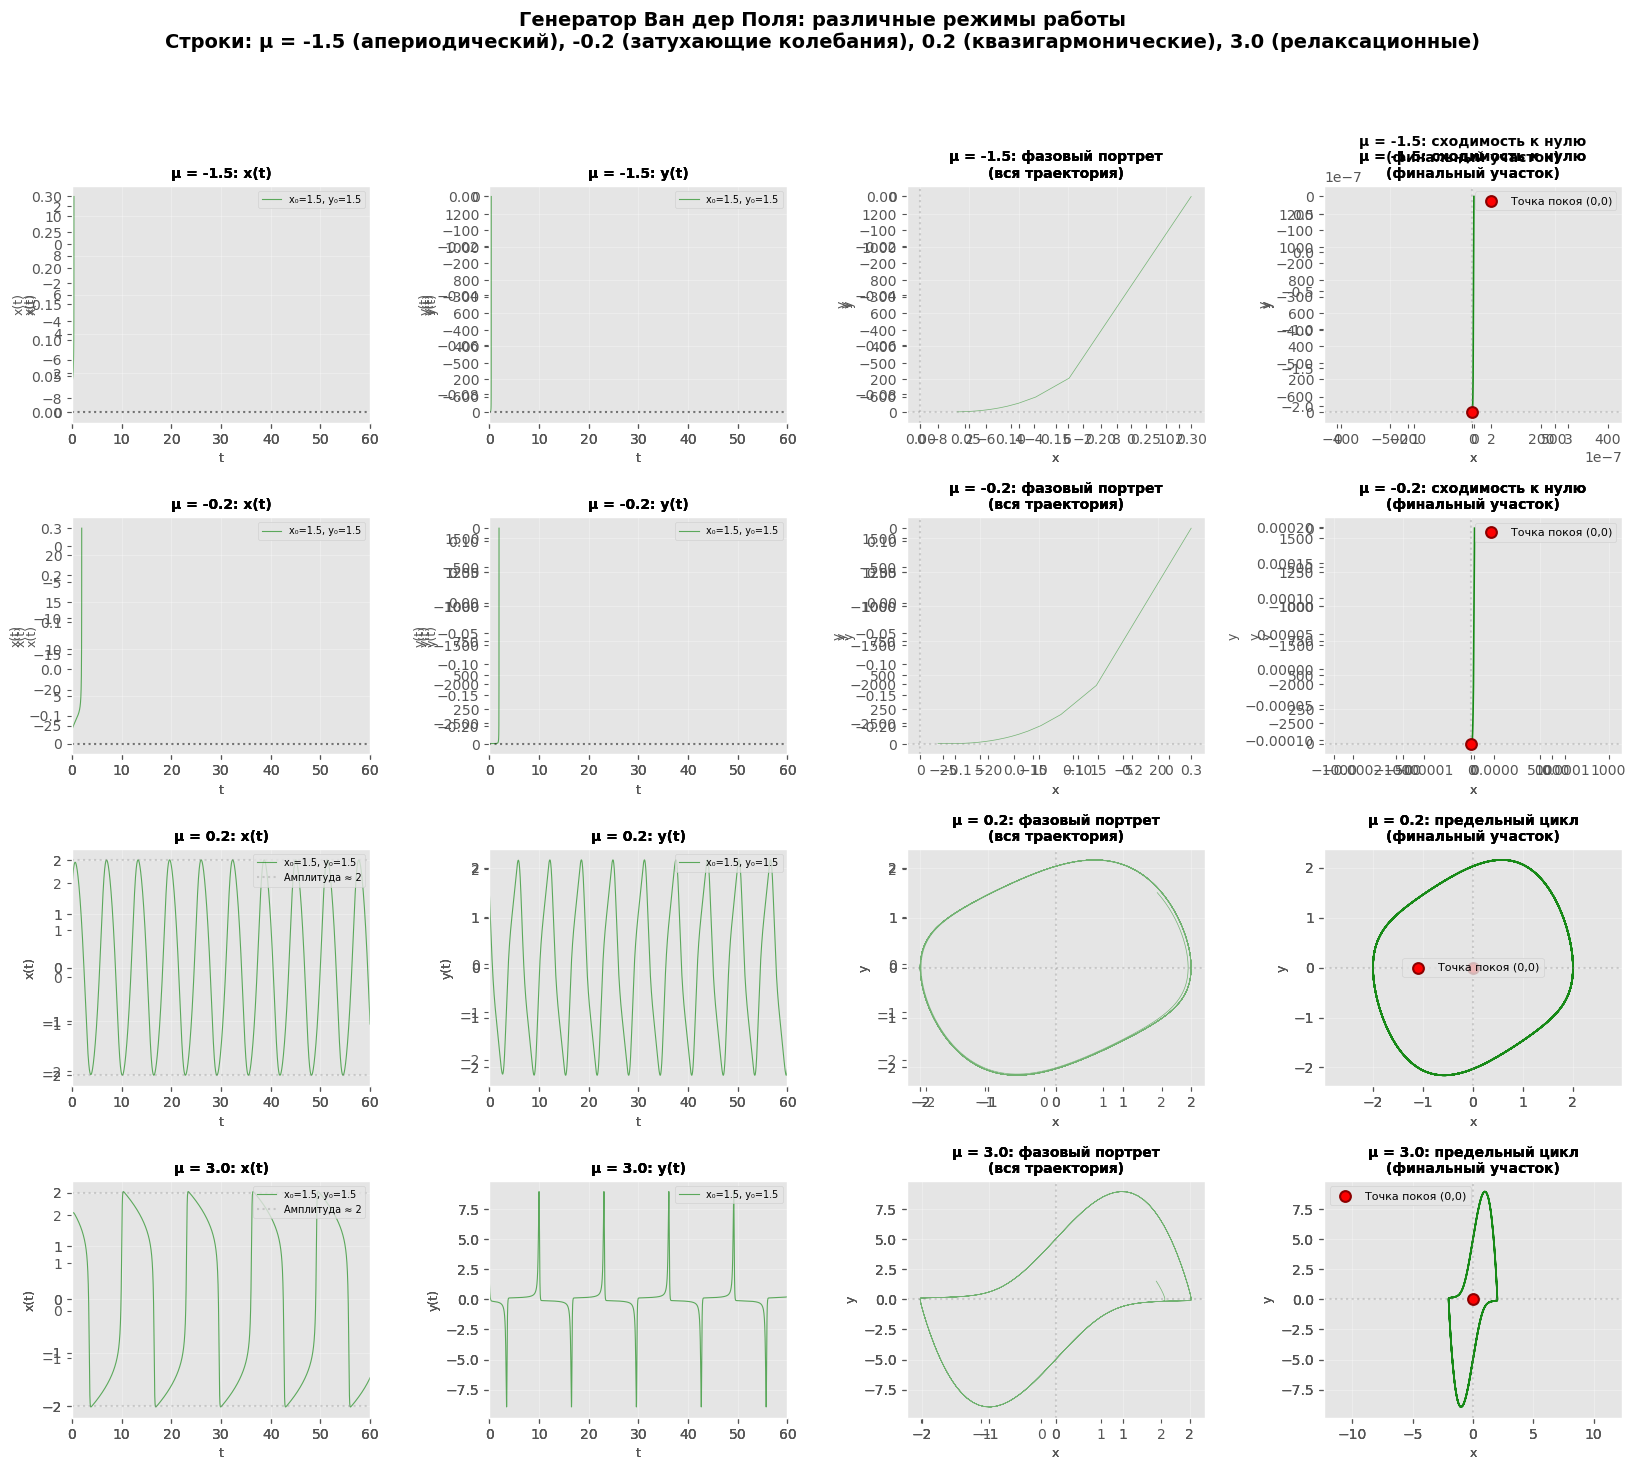

3. АНАЛИЗ ПРЕДЕЛЬНОГО ЦИКЛА
Исследуем предельный цикл при μ = 1.0

Характеристики предельного цикла при μ = 1.0:
  Период колебаний: 7.629 ± 0.004
  Амплитуда x: 2.020 ± 0.000
  Количество полных циклов: 5

ЦИКЛ УСТОЙЧИВЫЙ:
    - Амплитуда постоянна (отклонение < 1%)
    - Период стабилен
    - Траектории изнутри и снаружи стремятся к циклу
    - Цикл является аттрактором


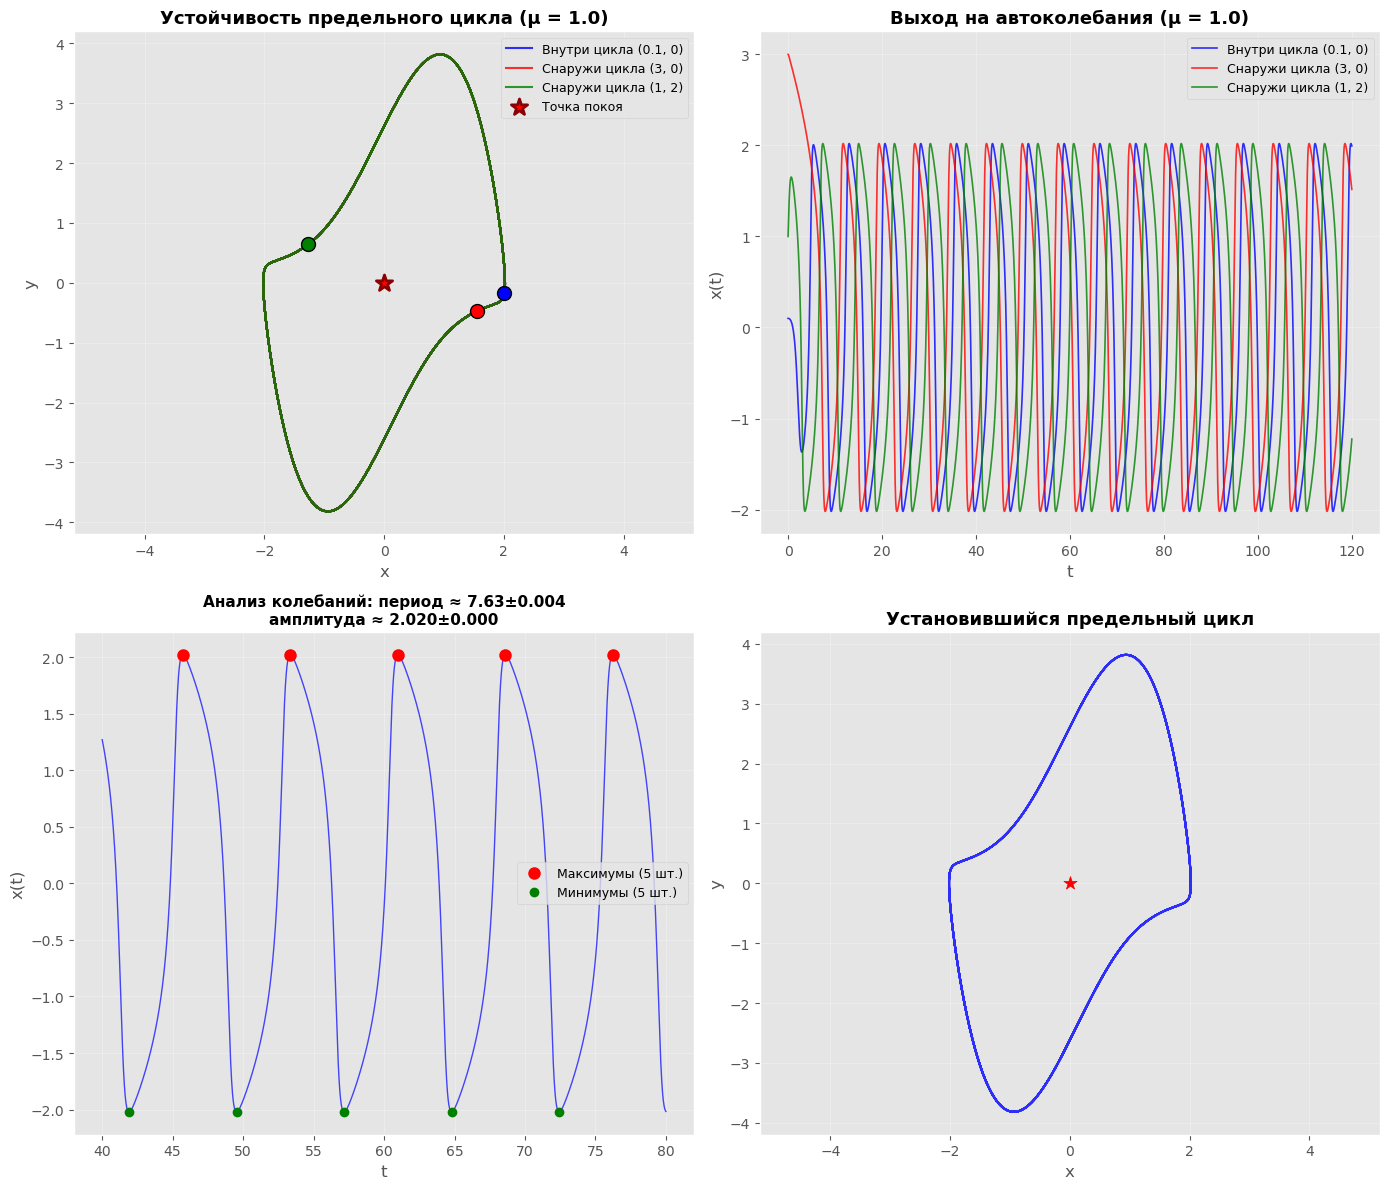

4. ПАРАМЕТРИЧЕСКАЯ ДИАГРАММА


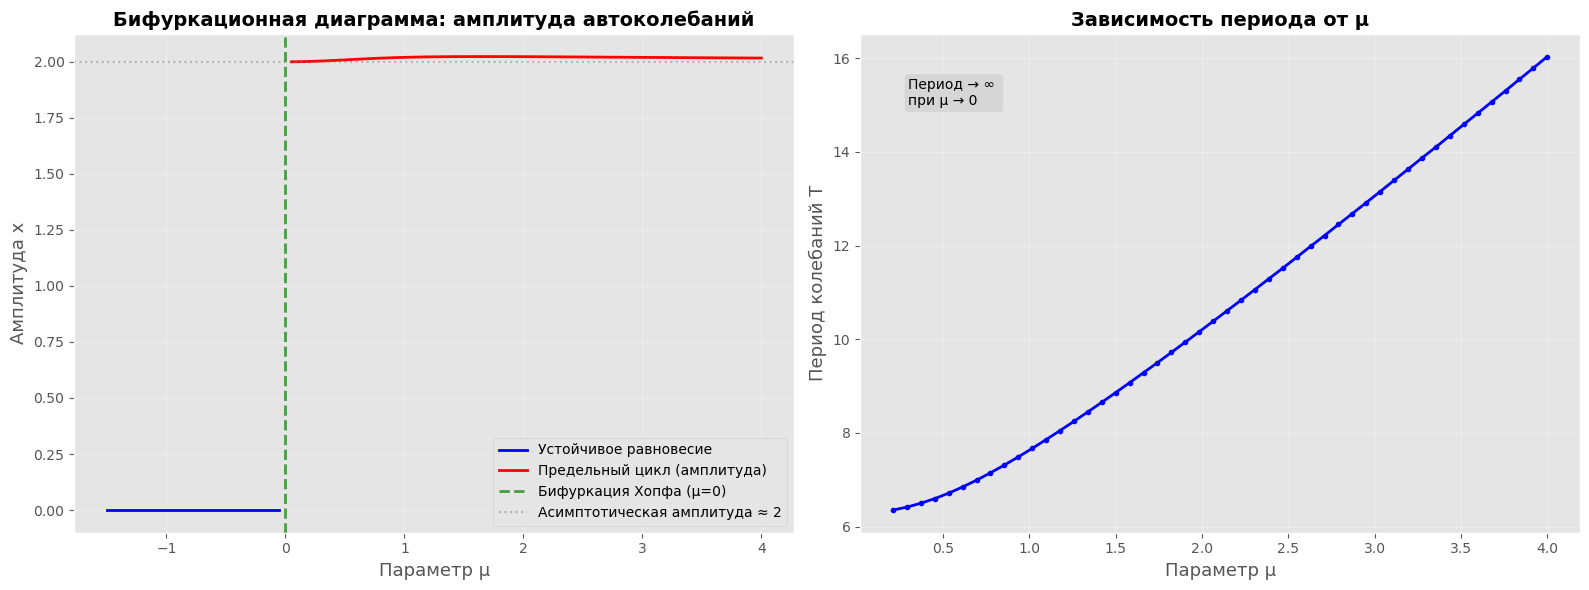

In [24]:
print("1. КАЧЕСТВЕННЫЙ АНАЛИЗ ПО ПЕРВОМУ ПРИБЛИЖЕНИЮ")

def vdp(t, z, mu):
    x, y = z
    dxdt = y
    dydt = 2 * mu * (1 - x**2) * y - x
    return [dxdt, dydt]

print("Система: dx/dt = y, dy/dt = 2μ(1-x²)y - x")
print("\nЕдинственная точка покоя: (0, 0)")
print("\nЛинеаризованная система в окрестности (0,0):")
print("J = [[0, 1], [-1, 2μ]]")
print("Характеристическое уравнение: λ² - 2μλ + 1 = 0")
print("Собственные значения: λ₁,₂ = μ ± √(μ² - 1)")
print("\nБифуркационные значения параметра μ:")
print("  μ = -1: переход узел → фокус (для μ < 0)")
print("  μ = 0:  бифуркация Андронова-Хопфа")
print("  μ = 1:  переход фокус → узел (для μ > 0)")

print("\nРежимы работы генератора:")
mu_ranges = [
    "μ < -1:  Устойчивый узел (апериодический режим)",
    "-1 < μ < 0: Устойчивый фокус (затухающие колебания)",
    "μ = 0:  Точка бифуркации (центр по первому приближению)",
    "0 < μ < 1: Неустойчивый фокус + устойчивый предельный цикл (квазигармонические автоколебания)",
    "μ > 1:  Неустойчивый узел + устойчивый предельный цикл (релаксационные автоколебания)"]
for r in mu_ranges:
    print(f"{r}")

print("\nПараметрическая диаграмма:")
print(" Бифуркация Андронова-Хопфа при μ = 0")
print(" При μ < 0: устойчивое состояние равновесия, аттрактор - точка")
print(" При μ > 0: рождается устойчивый предельный цикл, амплитуда ~ 2")


print("2. МОДЕЛИРОВАНИЕ РАЗЛИЧНЫХ РЕЖИМОВ")

t_span = [0, 60]
t_eval = np.linspace(t_span[0], t_span[1], 6000)

# μ для 4 различных режимов
mu_regimes = {
    'Апериодический режим\n(устойчивый узел)': -1.5,
    'Затухающие колебания\n(устойчивый фокус)': -0.2,
    'Квазигармонические\nавтоколебания': 0.2,
    'Релаксационные\nавтоколебания': 3.0}

# Начальные условия для демонстрации сходимости
initial_conditions = [
    [2.5, 0.0],   # далеко от начала
    [0.3, 0.0],   # близко к началу (для μ<0 покажет сходимость к нулю)
    [1.5, 1.5]    # еще одно условие
]

print("Моделируемые режимы:")
for name, mu in mu_regimes.items():
    print(f" μ = {mu}: {name.replace(chr(10), ' ')}")

fig = plt.figure(figsize=(20, 16))
gs = GridSpec(4, 4, figure=fig, hspace=0.4, wspace=0.4)

regime_names = list(mu_regimes.keys())
mu_values = list(mu_regimes.values())

for i, (regime_name, mu) in enumerate(zip(regime_names, mu_values)):
    if mu < 0:
        regime_type = "Затухание"
    else:
        regime_type = "Автоколебания"
    
    # Для каждого режима берем несколько начальных условий
    colors = ['blue', 'red', 'green']
    linewidths = [1.5, 1.0, 0.8]
    alphas = [1.0, 0.7, 0.6]
    
    for j, ic in enumerate(initial_conditions):
        # Решаем систему
        sol = solve_ivp(vdp, t_span, ic, args=(mu,), 
                       t_eval=t_eval, method='RK45',
                       rtol=1e-9, atol=1e-12, max_step=0.01)
        x, y = sol.y
        t = sol.t
        
        # График x(t)
        ax1 = fig.add_subplot(gs[i, 0])
        ax1.plot(t, x, color=colors[j], linewidth=linewidths[j], 
                alpha=alphas[j], label=f'x₀={ic[0]}, y₀={ic[1]}')
        if mu < 0:
            ax1.axhline(y=0, color='black', linestyle=':', alpha=0.5)
        else:
            ax1.axhline(y=2, color='gray', linestyle=':', alpha=0.3, label='Амплитуда ≈ 2')
            ax1.axhline(y=-2, color='gray', linestyle=':', alpha=0.3)
        ax1.set_xlabel('t', fontsize=9)
        ax1.set_ylabel('x(t)', fontsize=9)
        ax1.set_title(f'μ = {mu}: x(t)', fontsize=10, fontweight='bold')
        ax1.legend(fontsize=7, loc='upper right')
        ax1.grid(True, alpha=0.3)
        ax1.set_xlim(0, 60)
        
        # График y(t)
        ax2 = fig.add_subplot(gs[i, 1])
        ax2.plot(t, y, color=colors[j], linewidth=linewidths[j], 
                alpha=alphas[j], label=f'x₀={ic[0]}, y₀={ic[1]}')
        if mu < 0:
            ax2.axhline(y=0, color='black', linestyle=':', alpha=0.5)
        ax2.set_xlabel('t', fontsize=9)
        ax2.set_ylabel('y(t)', fontsize=9)
        ax2.set_title(f'μ = {mu}: y(t)', fontsize=10, fontweight='bold')
        ax2.legend(fontsize=7, loc='upper right')
        ax2.grid(True, alpha=0.3)
        ax2.set_xlim(0, 60)
        
        # Полный фазовый портрет
        ax3 = fig.add_subplot(gs[i, 2])
        ax3.plot(x, y, color=colors[j], linewidth=0.5, alpha=0.5)
        ax3.set_xlabel('x', fontsize=9)
        ax3.set_ylabel('y', fontsize=9)
        ax3.set_title(f'μ = {mu}: фазовый портрет\n(вся траектория)', fontsize=10, fontweight='bold')
        ax3.grid(True, alpha=0.3)
        ax3.axhline(y=0, color='gray', linestyle=':', alpha=0.3)
        ax3.axvline(x=0, color='gray', linestyle=':', alpha=0.3)
        
        # Финальный участок фазового портрета
        ax4 = fig.add_subplot(gs[i, 3])
        # Берем последние 40% для μ<0 и последние 80% для μ>0
        if mu < 0:
            start_idx = int(0.6 * len(x))
        else:
            start_idx = int(0.2 * len(x))
        
        ax4.plot(x[start_idx:], y[start_idx:], color=colors[j], 
                linewidth=1.2, alpha=0.9)
        ax4.scatter(0, 0, color='red', s=60, zorder=5, 
                   edgecolors='darkred', linewidths=1.5, label='Точка покоя (0,0)')
        ax4.set_xlabel('x', fontsize=9)
        ax4.set_ylabel('y', fontsize=9)
        
        if mu < 0:
            ax4.set_title(f'μ = {mu}: сходимость к нулю\n(финальный участок)', 
                         fontsize=10, fontweight='bold')
        else:
            ax4.set_title(f'μ = {mu}: предельный цикл\n(финальный участок)', 
                         fontsize=10, fontweight='bold')
        ax4.legend(fontsize=8)
        ax4.grid(True, alpha=0.3)
        ax4.axhline(y=0, color='gray', linestyle=':', alpha=0.3)
        ax4.axvline(x=0, color='gray', linestyle=':', alpha=0.3)
        ax4.axis('equal')

# Добавляем общий заголовок
fig.suptitle('Генератор Ван дер Поля: различные режимы работы\n' +
             'Строки: μ = -1.5 (апериодический), -0.2 (затухающие колебания), ' +
             '0.2 (квазигармонические), 3.0 (релаксационные)',
             fontsize=14, fontweight='bold', y=0.99)
plt.tight_layout()
plt.show()


print("3. АНАЛИЗ ПРЕДЕЛЬНОГО ЦИКЛА")

# Детальное исследование для μ > 0
mu_cycle = 1.0
print(f"Исследуем предельный цикл при μ = {mu_cycle}")

# Берем несколько начальных условий: внутри цикла и снаружи
test_conditions = [
    [0.1, 0.0],    # внутри предполагаемого цикла
    [3.0, 0.0],    # снаружи предполагаемого цикла
    [1.0, 2.0],    # снаружи
]
fig_cycle, axes = plt.subplots(2, 2, figsize=(14, 12))

# Длительное интегрирование для установления
t_long = [0, 120]
t_long_eval = np.linspace(0, 120, 10000)

colors_cycle = ['blue', 'red', 'green']
labels_cycle = ['Внутри цикла (0.1, 0)', 'Снаружи цикла (3, 0)', 'Снаружи цикла (1, 2)']

# Подграфик 1: Фазовый портрет с разными начальными условиями
ax1 = axes[0, 0]
for j, ic in enumerate(test_conditions):
    sol = solve_ivp(vdp, t_long, ic, args=(mu_cycle,),
                   t_eval=t_long_eval, method='RK45',
                   rtol=1e-9, atol=1e-12)
    x, y = sol.y
    start_idx = int(0.3 * len(x))
    ax1.plot(x[start_idx:], y[start_idx:], color=colors_cycle[j], 
            linewidth=1.5, alpha=0.8, label=labels_cycle[j])
    # Отмечаем начальную точку финального участка
    ax1.scatter(x[start_idx], y[start_idx], color=colors_cycle[j], 
               s=100, edgecolors='black', linewidths=1, zorder=5)

ax1.scatter(0, 0, color='red', s=150, zorder=6, marker='*',
           edgecolors='darkred', linewidths=2, label='Точка покоя')
ax1.set_xlabel('x', fontsize=12)
ax1.set_ylabel('y', fontsize=12)
ax1.set_title(f'Устойчивость предельного цикла (μ = {mu_cycle})', fontsize=13, fontweight='bold')
ax1.legend(fontsize=9, loc='upper right')
ax1.grid(True, alpha=0.3)
ax1.axis('equal')

# Подграфик 2: x(t) для разных нач. условий
ax2 = axes[0, 1]
for j, ic in enumerate(test_conditions):
    sol = solve_ivp(vdp, t_long, ic, args=(mu_cycle,),
                   t_eval=t_long_eval, method='RK45',
                   rtol=1e-9, atol=1e-12)
    ax2.plot(sol.t, sol.y[0], color=colors_cycle[j], 
            linewidth=1.2, alpha=0.8, label=labels_cycle[j])
ax2.set_xlabel('t', fontsize=12)
ax2.set_ylabel('x(t)', fontsize=12)
ax2.set_title(f'Выход на автоколебания (μ = {mu_cycle})', fontsize=13, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

# Подграфик 3: Амплитудный спектр для одного решения
ax3 = axes[1, 0]
sol_final = solve_ivp(vdp, [0, 80], [2.0, 0.0], args=(mu_cycle,),
                     t_eval=np.linspace(40, 80, 4000), method='RK45',
                     rtol=1e-9, atol=1e-12)
x_final = sol_final.y[0]
t_final = sol_final.t

# Находим экстремумы
from scipy.signal import argrelextrema
maxima_idx = argrelextrema(x_final, np.greater)[0]
minima_idx = argrelextrema(x_final, np.less)[0]

if len(maxima_idx) > 1:
    periods = np.diff(t_final[maxima_idx])
    amplitudes_max = x_final[maxima_idx]
    amplitudes_min = x_final[minima_idx]
    
    ax3.plot(t_final, x_final, 'b-', linewidth=1, alpha=0.7)
    ax3.plot(t_final[maxima_idx], x_final[maxima_idx], 'ro', 
            markersize=8, label=f'Максимумы ({len(maxima_idx)} шт.)')
    ax3.plot(t_final[minima_idx], x_final[minima_idx], 'go', 
            markersize=6, label=f'Минимумы ({len(minima_idx)} шт.)')
    
    period_mean = np.mean(periods)
    period_std = np.std(periods)
    amp_mean = np.mean(amplitudes_max)
    amp_std = np.std(amplitudes_max)
    
    ax3.set_xlabel('t', fontsize=12)
    ax3.set_ylabel('x(t)', fontsize=12)
    ax3.set_title(f'Анализ колебаний: период ≈ {period_mean:.2f}±{period_std:.3f}\n' +
                 f'амплитуда ≈ {amp_mean:.3f}±{amp_std:.3f}', 
                 fontsize=11, fontweight='bold')
    ax3.legend(fontsize=9)
    ax3.grid(True, alpha=0.3)
    
    print(f"\nХарактеристики предельного цикла при μ = {mu_cycle}:")
    print(f"  Период колебаний: {period_mean:.3f} ± {period_std:.3f}")
    print(f"  Амплитуда x: {amp_mean:.3f} ± {amp_std:.3f}")
    print(f"  Количество полных циклов: {len(maxima_idx)}")
    
    # Определение устойчивости
    if amp_std < 0.01 * amp_mean:
        print("\nЦИКЛ УСТОЙЧИВЫЙ:")
        print("    - Амплитуда постоянна (отклонение < 1%)")
        print("    - Период стабилен")
        print("    - Траектории изнутри и снаружи стремятся к циклу")
        print("    - Цикл является аттрактором")
    else:
        print("\n  Внимание: обнаружена нестабильность амплитуды")

# Подграфик 4: Проверка симметрии цикла
ax4 = axes[1, 1]
ax4.plot(x_final, sol_final.y[1], 'b-', linewidth=1.5, alpha=0.8)
ax4.scatter(0, 0, color='red', s=100, zorder=5, marker='*')
ax4.set_xlabel('x', fontsize=12)
ax4.set_ylabel('y', fontsize=12)
ax4.set_title('Установившийся предельный цикл', fontsize=13, fontweight='bold')
ax4.grid(True, alpha=0.3)
ax4.axis('equal')

plt.tight_layout()
plt.show()


print("4. ПАРАМЕТРИЧЕСКАЯ ДИАГРАММА")

mu_span_neg = np.linspace(-1.5, -0.05, 20)
mu_span_pos = np.linspace(0.05, 4.0, 50)
mu_span = np.concatenate([mu_span_neg, [0.0], mu_span_pos])

amplitude_x = []
periods_x = []
stability = []

for mu in mu_span:
    if mu <= 0:
        # При μ ≤ 0: решения стремятся к нулю
        amplitude_x.append(0.0)
        periods_x.append(0.0)
        stability.append('Устойчивая точка')
    else:
        # При μ > 0: существует предельный цикл
        sol = solve_ivp(vdp, [0, 100], [2.0, 0.0], args=(mu,),
                       t_eval=np.linspace(50, 100, 5000),
                       method='RK45', rtol=1e-9, atol=1e-12, max_step=0.01)
        x = sol.y[0]
        
        # Находим амплитуду
        maxima = argrelextrema(x, np.greater)[0]
        if len(maxima) > 0:
            amp = np.mean(x[maxima])
            amplitude_x.append(amp)
            
            # Оценка периода
            if len(maxima) > 1:
                t_cycle = sol.t[maxima]
                T = np.mean(np.diff(t_cycle))
                periods_x.append(T)
            else:
                periods_x.append(0)
        else:
            amplitude_x.append(0)
            periods_x.append(0)
        
        stability.append('Предельный цикл')

amplitude_x = np.array(amplitude_x)
periods_x = np.array(periods_x)

# Построение параметрической диаграммы
fig_bif, (ax_amp, ax_per) = plt.subplots(1, 2, figsize=(16, 6))

# Диаграмма амплитуды
ax_amp.plot(mu_span[mu_span < 0], amplitude_x[mu_span < 0], 
           'b-', linewidth=2, label='Устойчивое равновесие')
ax_amp.plot(mu_span[mu_span > 0], amplitude_x[mu_span > 0], 
           'r-', linewidth=2, label='Предельный цикл (амплитуда)')
ax_amp.axvline(x=0, color='green', linestyle='--', linewidth=2, 
              alpha=0.7, label='Бифуркация Хопфа (μ=0)')
ax_amp.axhline(y=2, color='gray', linestyle=':', alpha=0.5, 
              label='Асимптотическая амплитуда ≈ 2')
ax_amp.set_xlabel('Параметр μ', fontsize=13)
ax_amp.set_ylabel('Амплитуда x', fontsize=13)
ax_amp.set_title('Бифуркационная диаграмма: амплитуда автоколебаний', 
                fontsize=14, fontweight='bold')
ax_amp.legend(fontsize=10)
ax_amp.grid(True, alpha=0.3)

# # Добавляем аннотации режимов
# ax_amp.annotate('УСТОЙЧИВЫЙ\nФОКУС', xy=(-0.8, 0.1), fontsize=11,
#                bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
# ax_amp.annotate('УСТОЙЧИВЫЙ\nУЗЕЛ', xy=(-1.3, 0.1), fontsize=11,
#                bbox=dict(boxstyle='round', facecolor='lightcyan', alpha=0.8))
# ax_amp.annotate('КВАЗИГАРМОНИЧЕСКИЕ\nАВТОКОЛЕБАНИЯ', xy=(0.5, 1.8), fontsize=10,
#                bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
# ax_amp.annotate('РЕЛАКСАЦИОННЫЕ\nАВТОКОЛЕБАНИЯ', xy=(2.5, 2.0), fontsize=10,
#                bbox=dict(boxstyle='round', facecolor='lightsalmon', alpha=0.8))

# Диаграмма периода
ax_per.plot(mu_span[mu_span > 0.2], periods_x[mu_span > 0.2], 
           'b-', linewidth=2, marker='o', markersize=3)
ax_per.set_xlabel('Параметр μ', fontsize=13)
ax_per.set_ylabel('Период колебаний T', fontsize=13)
ax_per.set_title('Зависимость периода от μ', fontsize=14, fontweight='bold')
ax_per.grid(True, alpha=0.3)
ax_per.annotate('Период → ∞ \nпри μ → 0', xy=(0.3, 15), fontsize=10,
               bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))

plt.tight_layout()
plt.show()

#### Брюсселятор

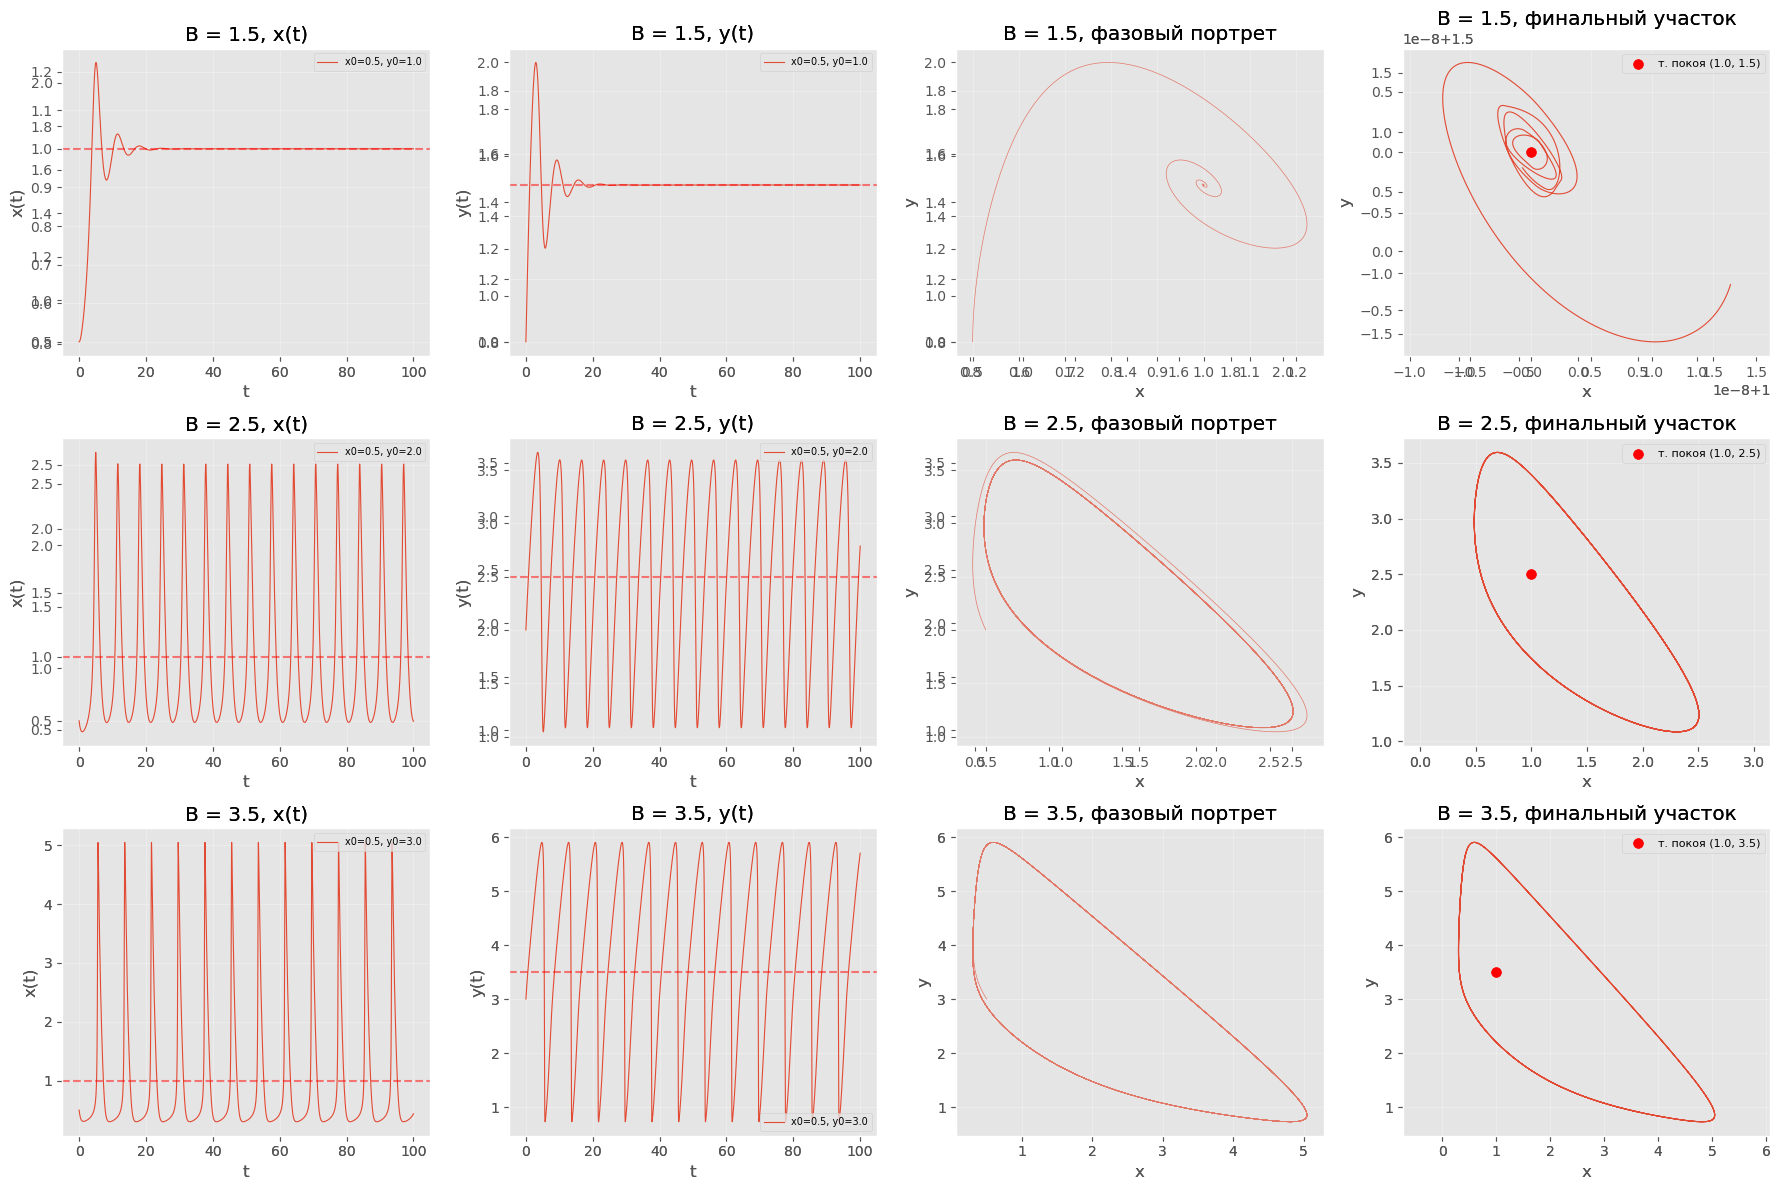

АНАЛИЗ УСТОЙЧИВОСТИ ТОЧКИ ПОКОЯ ДЛЯ РАЗНЫХ B

B = 1.5
  Точка покоя: x* = 1.0, y* = 1.5
  Собственные значения: λ₁,₂ = -0.2500+0.9682j, -0.2500-0.9682j
  След матрицы: τ = -0.50
  Определитель: Δ = 1.00
  Дискриминант: D = -3.75
  ВЫВОД: Устойчивый фокус
  → Режим: затухающие колебания к стационарной точке

B = 2.0
  Точка покоя: x* = 1.0, y* = 2.0
  Собственные значения: λ₁,₂ = -0.0000+1.0000j, -0.0000-1.0000j
  След матрицы: τ = 0.00
  Определитель: Δ = 1.00
  Дискриминант: D = -4.00
  ВЫВОД: Устойчивый фокус
  → Точка бифуркации Хопфа

B = 2.5
  Точка покоя: x* = 1.0, y* = 2.5
  Собственные значения: λ₁,₂ = 0.2500+0.9682j, 0.2500-0.9682j
  След матрицы: τ = 0.50
  Определитель: Δ = 1.00
  Дискриминант: D = -3.75
  ВЫВОД: Неустойчивый фокус
  → Режим: автоколебания (предельный цикл)

B = 3.5
  Точка покоя: x* = 1.0, y* = 3.5
  Собственные значения: λ₁,₂ = 0.7500+0.6614j, 0.7500-0.6614j
  След матрицы: τ = 1.50
  Определитель: Δ = 1.00
  Дискриминант: D = -1.75
  ВЫВОД: Неустойчивый ф

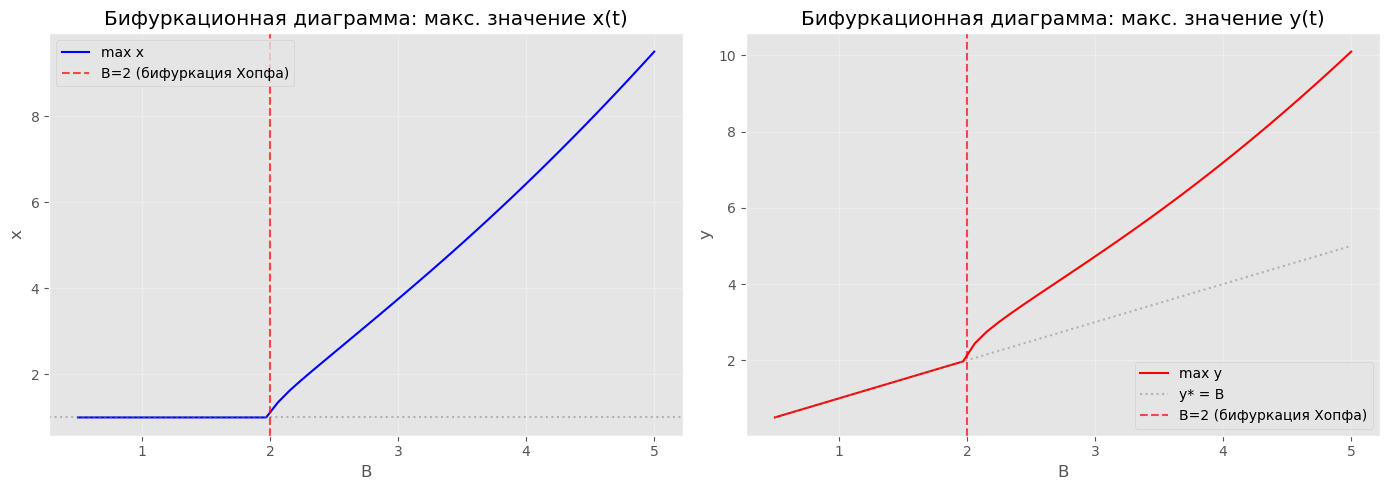


РОЖДЕНИЕ ПРЕДЕЛЬНОГО ЦИКЛА ПРИ B > 2
B = 1.8: Затухание к точке
B = 2.0: Граница устойчивости
B = 2.2: Автоколебания
B = 2.5: Автоколебания


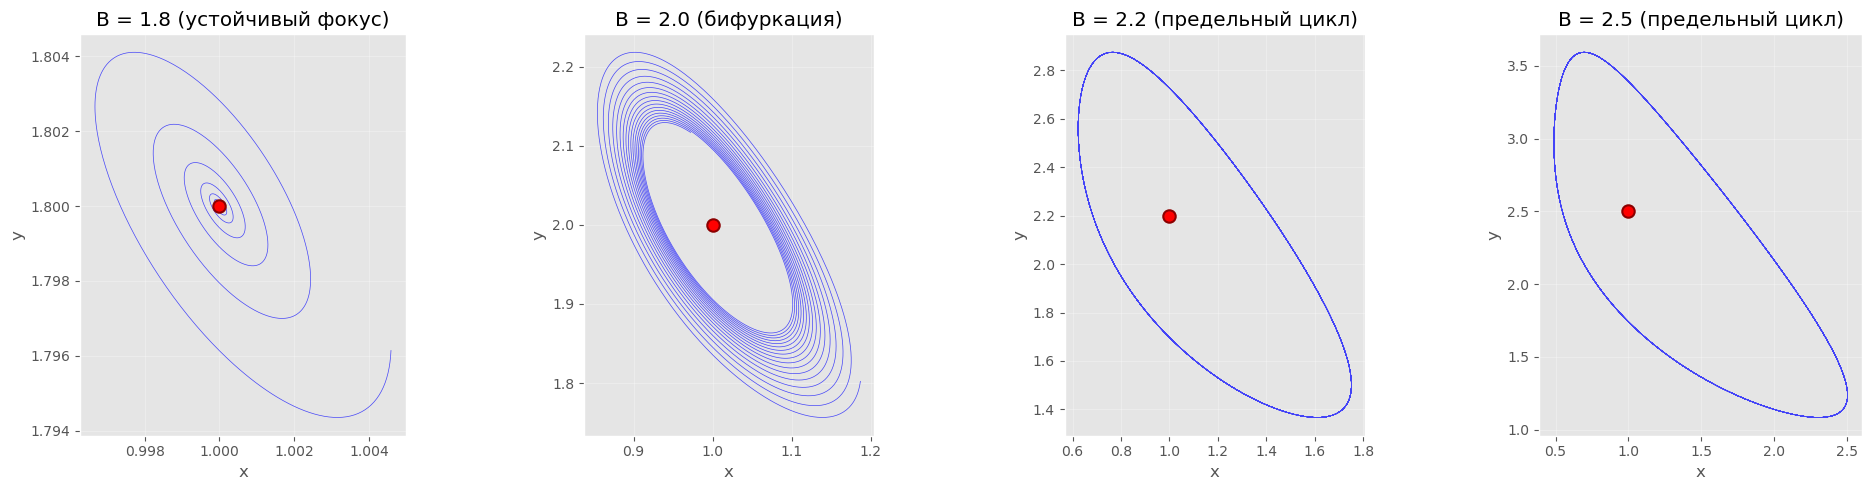

In [27]:
# Система Брюсселятора
def brusselator(t, z, A, B):
    x, y = z
    dxdt = A - (B + 1) * x + x**2 * y
    dydt = B * x - x**2 * y
    return [dxdt, dydt]

# Параметры
A = 1.0  # фиксированный параметр
# Выбираем B для качественно разных режимов:
# B < 2 - устойчивый фокус
# B = 2 - точка бифуркации Хопфа
# B > 2 - предельный цикл
B_values = [1.5, 2.5, 3.5]

# Время моделирования
t_span = [0, 100]
t_eval = np.linspace(t_span[0], t_span[1], 10000)

# Стационарная точка
x_star = A
# y_star = B/A = B при A=1

# Создаем фигуру для всех режимов
fig = plt.figure(figsize=(18, 12))
gs = GridSpec(3, 4, figure=fig)

for i, B in enumerate(B_values):
    y_star = B / A  # стационарное значение y
    
    # Две разные начальные точки для демонстрации сходимости
    initial_conditions = [
        [1.5, y_star + 0.5],  # первая траектория
        [0.5, y_star - 0.5]   # вторая траектория
    ]
    
    for ic in initial_conditions:
        # Решаем систему
        sol = solve_ivp(
            brusselator, t_span, ic, args=(A, B),
            t_eval=t_eval, method='RK45',
            rtol=1e-9, atol=1e-12
        )
        x, y = sol.y
        t = sol.t
        
        # График x(t)
        ax1 = fig.add_subplot(gs[i, 0])
        ax1.plot(t, x, linewidth=0.8, label=f'x0={ic[0]}, y0={ic[1]}')
        ax1.axhline(y=x_star, color='red', linestyle='--', alpha=0.5)
        ax1.set_xlabel('t')
        ax1.set_ylabel('x(t)')
        ax1.set_title(f'B = {B}, x(t)')
        ax1.legend(fontsize=7)
        ax1.grid(True, alpha=0.3)
        
        # График y(t)
        ax2 = fig.add_subplot(gs[i, 1])
        ax2.plot(t, y, linewidth=0.8, label=f'x0={ic[0]}, y0={ic[1]}')
        ax2.axhline(y=y_star, color='red', linestyle='--', alpha=0.5)
        ax2.set_xlabel('t')
        ax2.set_ylabel('y(t)')
        ax2.set_title(f'B = {B}, y(t)')
        ax2.legend(fontsize=7)
        ax2.grid(True, alpha=0.3)
        
        # Фазовый портрет (полный)
        ax3 = fig.add_subplot(gs[i, 2])
        ax3.plot(x, y, linewidth=0.5, alpha=0.7)
        ax3.set_xlabel('x')
        ax3.set_ylabel('y')
        ax3.set_title(f'B = {B}, фазовый портрет')
        ax3.grid(True, alpha=0.3)
        
        # Фазовый портрет (конечный участок для видимости цикла)
        ax4 = fig.add_subplot(gs[i, 3])
        # Берем последние 30% траектории
        start_idx = int(0.7 * len(x))
        ax4.plot(x[start_idx:], y[start_idx:], linewidth=0.8)
        ax4.scatter(x_star, y_star, color='red', s=50, zorder=5, 
                   label=f'т. покоя ({x_star:.1f}, {y_star:.1f})')
        ax4.set_xlabel('x')
        ax4.set_ylabel('y')
        ax4.set_title(f'B = {B}, финальный участок')
        ax4.legend(fontsize=8)
        ax4.grid(True, alpha=0.3)
        ax4.axis('equal')

plt.tight_layout()
plt.show()


print("АНАЛИЗ УСТОЙЧИВОСТИ ТОЧКИ ПОКОЯ ДЛЯ РАЗНЫХ B")

for B in [1.5, 2.0, 2.5, 3.5]:
    # Матрица Якоби в точке покоя (A, B/A)
    # J = [[B-1, 1], [-B, -1]]
    J = np.array([[B - 1, 1],
                  [-B, -1]])
    
    eigvals = np.linalg.eigvals(J)
    trace = np.trace(J)
    det = np.linalg.det(J)
    discriminant = trace**2 - 4*det
    
    real_min = np.min(np.real(eigvals))
    
    print(f"\nB = {B}")
    print(f"  Точка покоя: x* = {A}, y* = {B/A}")
    print(f"  Собственные значения: λ₁,₂ = {eigvals[0]:.4f}, {eigvals[1]:.4f}")
    print(f"  След матрицы: τ = {trace:.2f}")
    print(f"  Определитель: Δ = {det:.2f}")
    print(f"  Дискриминант: D = {discriminant:.2f}")
    
    if np.all(np.real(eigvals) < 0):
        print(f"  ВЫВОД: Устойчивый ", end="")
    elif np.all(np.real(eigvals) > 0):
        print(f"  ВЫВОД: Неустойчивый ", end="")
    else:
        print(f"  ВЫВОД: Седло ", end="")
    
    if discriminant < 0:
        print("фокус")
    else:
        print("узел")
    
    if B < 2:
        print("  → Режим: затухающие колебания к стационарной точке")
    elif B > 2:
        print("  → Режим: автоколебания (предельный цикл)")
    else:
        print("  → Точка бифуркации Хопфа")


print("ПОСТРОЕНИЕ БИФУРКАЦИОННОЙ ДИАГРАММЫ")
B_range = np.linspace(0.5, 5.0, 50)
x_amplitudes = []
y_amplitudes = []

for B in B_range:
    sol = solve_ivp(
        brusselator, [0, 200], [1.2, B],
        args=(A, B), t_eval=np.linspace(150, 200, 5000),
        method='RK45', rtol=1e-9, atol=1e-12
    )
    x, y = sol.y
    
    if B < 2:
        # Сходится к точке - амплитуда = 0
        x_amplitudes.append(x_star)
        y_amplitudes.append(B)
    else:
        # Предельный цикл - находим размах колебаний
        x_amplitudes.append(np.max(x))
        y_amplitudes.append(np.max(y))

x_amplitudes = np.array(x_amplitudes)
y_amplitudes = np.array(y_amplitudes)

fig2, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Диаграмма для x
ax1.plot(B_range, x_amplitudes, 'b-', linewidth=1.5, label='max x')
ax1.axhline(y=x_star, color='gray', linestyle=':', alpha=0.5)
ax1.axvline(x=2, color='red', linestyle='--', alpha=0.7, 
            label='B=2 (бифуркация Хопфа)')
ax1.set_xlabel('B')
ax1.set_ylabel('x')
ax1.set_title('Бифуркационная диаграмма: макс. значение x(t)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Диаграмма для y
ax2.plot(B_range, y_amplitudes, 'r-', linewidth=1.5, label='max y')
ax2.plot(B_range, B_range, 'gray', linestyle=':', alpha=0.5, label='y* = B')
ax2.axvline(x=2, color='red', linestyle='--', alpha=0.7,
            label='B=2 (бифуркация Хопфа)')
ax2.set_xlabel('B')
ax2.set_ylabel('y')
ax2.set_title('Бифуркационная диаграмма: макс. значение y(t)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


print("\nРОЖДЕНИЕ ПРЕДЕЛЬНОГО ЦИКЛА ПРИ B > 2")

fig3, axes = plt.subplots(1, 4, figsize=(20, 5))
B_demo = [1.8, 2.0, 2.2, 2.5]

for idx, B in enumerate(B_demo):
    sol = solve_ivp(
        brusselator, [0, 150], [1.5, B + 0.3],
        args=(A, B), t_eval=np.linspace(0, 150, 8000),
        method='RK45', rtol=1e-9, atol=1e-12
    )
    x, y = sol.y
    start = int(0.3 * len(x))
    
    ax = axes[idx]
    ax.plot(x[start:], y[start:], 'b-', linewidth=0.5, alpha=0.7)
    ax.scatter([A], [B/A], color='red', s=80, zorder=5, marker='o',
              edgecolors='darkred', linewidths=1.5)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    
    if B < 2:
        ax.set_title(f'B = {B} (устойчивый фокус)')
        status = "Затухание к точке"
    elif B == 2:
        ax.set_title(f'B = {B} (бифуркация)')
        status = "Граница устойчивости"
    else:
        ax.set_title(f'B = {B} (предельный цикл)')
        status = "Автоколебания"
    
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
    print(f"B = {B}: {status}")

plt.tight_layout()
plt.show()

#### Модель Холлинга–Тэннера

Рассчитанная точка покоя: N* = 7.9313, P* = 0.3966


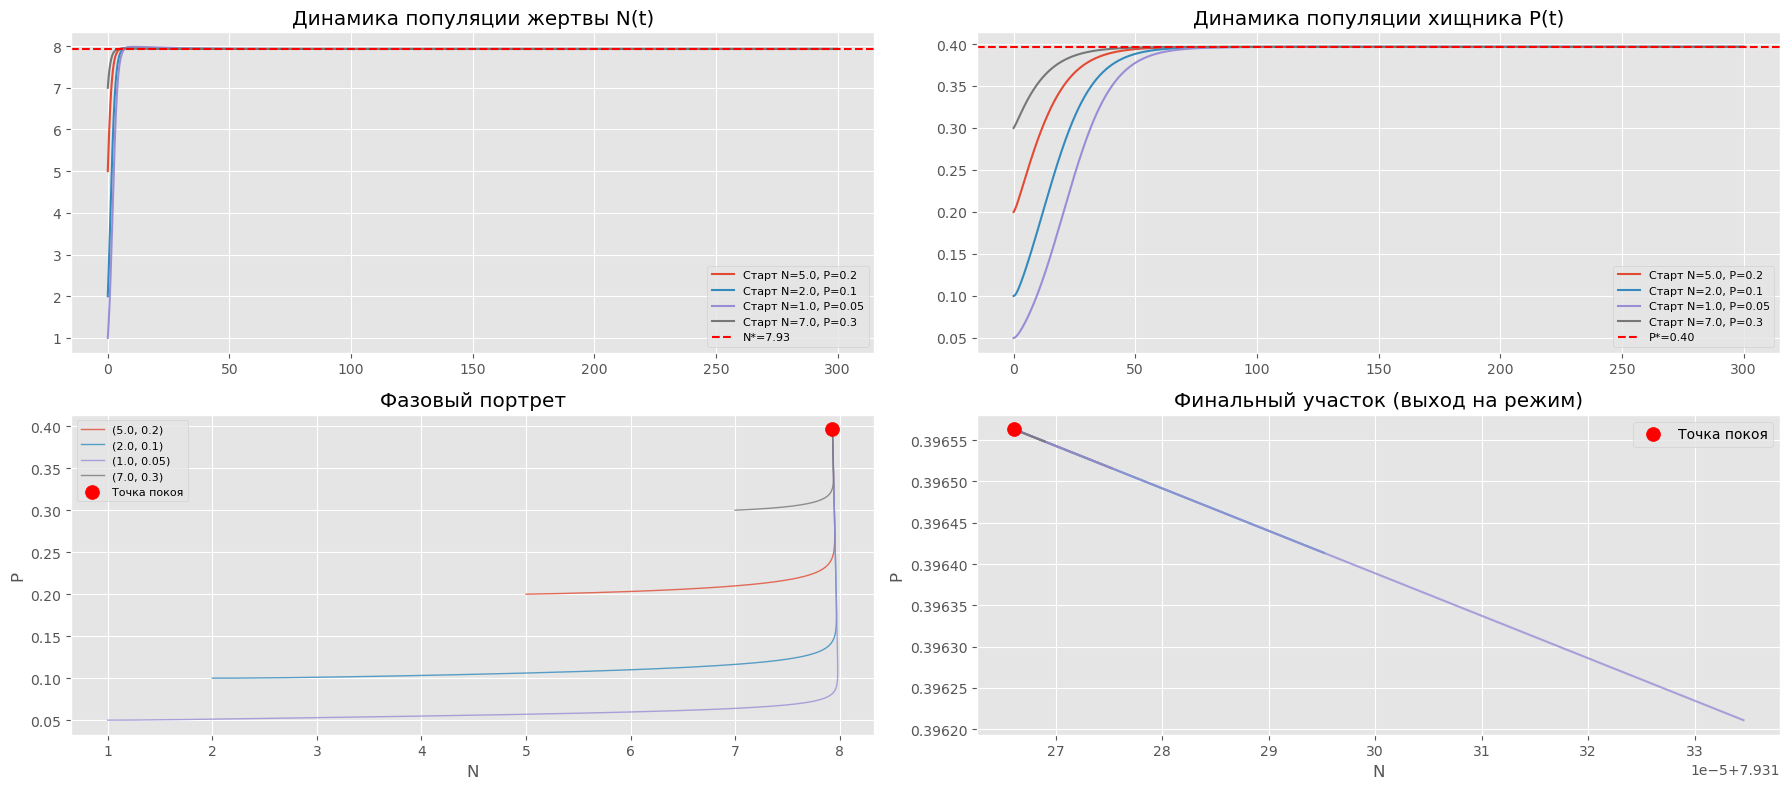

Собственные значения: [-0.9830535  -0.10097296]
Точка покоя УСТОЙЧИВА (предельного цикла нет)


In [20]:
r, K, w, s, J_param, D = 1.0, 8.0, 0.2, 0.1, 0.05, 1.3

# Правильная функция правых частей (чистая математика)
def holling_tanner_fixed(t, z):
    N, P = z
    # Никаких условий! Уравнение хищника может быть вычислено всегда.
    dNdt = r * N * (1 - N/K) - (w * N * P) / (D + N)
    dPdt = s * P * (1 - P / (J_param * N))
    return [dNdt, dPdt]

# 1. Аналитический расчет точки покоя
# Из P = J*N
# r*(1 - N/K) - w*J*N/(D+N) = 0
# Решаем квадратное уравнение: r*(1 - N/K)*(D+N) = w*J*N
# N^2 + N*(D - K + (w*J*K)/r) - K*D = 0
coeff_a = 1
coeff_b = D - K + (w * J_param * K) / r
coeff_c = -K * D

discriminant = coeff_b**2 - 4*coeff_a*coeff_c
N_star = (-coeff_b + np.sqrt(discriminant)) / (2*coeff_a)
P_star = J_param * N_star

print(f"Рассчитанная точка покоя: N* = {N_star:.4f}, P* = {P_star:.4f}")

# 2. Моделирование с разумными начальными условиями
# Жертва: около 2-6, Хищник: около 0.05-0.2 (что близко к P* = 0.3)
initial_conditions = [
    [5.0, 0.2],  # Близко к ожидаемому равновесию (6.0, 0.3)
    [2.0, 0.1],
    [1.0, 0.05],
    [7.0, 0.3]
]

t_span = [0, 300]
t_eval = np.linspace(t_span[0], t_span[1], 5000)

plt.figure(figsize=(18, 8))

# Графики N(t) и P(t)
plt.subplot(2, 2, 1)
plt.title('Динамика популяции жертвы N(t)')
for ic in initial_conditions:
    sol = solve_ivp(holling_tanner_fixed, t_span, ic, t_eval=t_eval, 
                    max_step=0.1, rtol=1e-9, atol=1e-12)
    plt.plot(sol.t, sol.y[0], label=f'Старт N={ic[0]}, P={ic[1]}')
plt.axhline(N_star, color='r', linestyle='--', label=f'N*={N_star:.2f}')
plt.legend(fontsize=8); plt.grid(True)

plt.subplot(2, 2, 2)
plt.title('Динамика популяции хищника P(t)')
for ic in initial_conditions:
    sol = solve_ivp(holling_tanner_fixed, t_span, ic, t_eval=t_eval, 
                    max_step=0.1, rtol=1e-9, atol=1e-12)
    plt.plot(sol.t, sol.y[1], label=f'Старт N={ic[0]}, P={ic[1]}')
plt.axhline(P_star, color='r', linestyle='--', label=f'P*={P_star:.2f}')
plt.legend(fontsize=8); plt.grid(True)

# Фазовый портрет (полный)
plt.subplot(2, 2, 3)
plt.title('Фазовый портрет')
for ic in initial_conditions:
    sol = solve_ivp(holling_tanner_fixed, t_span, ic, t_eval=t_eval, 
                    max_step=0.1, rtol=1e-9, atol=1e-12)
    plt.plot(sol.y[0], sol.y[1], linewidth=1, alpha=0.8, 
             label=f'({ic[0]}, {ic[1]})')
plt.scatter(N_star, P_star, color='red', s=100, zorder=5, label='Точка покоя')
plt.xlabel('N'); plt.ylabel('P'); plt.legend(fontsize=8); plt.grid(True)

# Фазовый портрет (финал)
plt.subplot(2, 2, 4)
plt.title('Финальный участок (выход на режим)')
for ic in initial_conditions:
    sol = solve_ivp(holling_tanner_fixed, t_span, ic, t_eval=t_eval, 
                    max_step=0.1, rtol=1e-9, atol=1e-12)
    # Берем последние 70% траектории
    cut = int(0.3 * len(sol.y[0]))
    plt.plot(sol.y[0][cut:], sol.y[1][cut:], linewidth=1.5, alpha=0.8)
plt.scatter(N_star, P_star, color='red', s=100, zorder=5, label='Точка покоя')
plt.xlabel('N'); plt.ylabel('P'); plt.legend(); plt.grid(True)

plt.tight_layout()
plt.show()

# Проверка устойчивости через собственные значения
import sympy as sp
N_s, P_s = sp.symbols('N_s P_s')
dN = r*N_s*(1 - N_s/K) - w*N_s*P_s/(D+N_s)
dP = s*P_s*(1 - P_s/(J_param*N_s))
J_mat = sp.Matrix([[sp.diff(dN, N_s), sp.diff(dN, P_s)],
                   [sp.diff(dP, N_s), sp.diff(dP, P_s)]])
J_val = np.array(J_mat.subs({N_s: N_star, P_s: P_star}), dtype=float)
eig = np.linalg.eigvals(J_val)
print(f"Собственные значения: {eig}")
if np.all(np.real(eig) < 0):
    print("Точка покоя УСТОЙЧИВА (предельного цикла нет)")
else:
    print("Точка покоя НЕУСТОЙЧИВА (возможен предельный цикл)")